# Stock Price Forecasting Project

## Objective
The goal of this project is to forecast the **next day closing price** of a stock using historical stock market data.  
The workflow begins with data understanding and stationarity analysis, followed by baseline forecasting models and then more advanced statistical time series models.

## Project Flow
1. Load and inspect the dataset  
2. Understand and explain all features  
3. Perform exploratory data analysis  
4. Check whether the series is stationary or non-stationary  
5. Convert the series into stationary form if needed  
6. Build baseline models such as naive forecast and moving average  
7. Prepare for advanced statistical time series models

## Step 1: Import Libraries

In this step, we import the required Python libraries for:
- data handling
- visualization
- stationarity testing
- model evaluation

These libraries will be used throughout the project.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:


# Load dataset
df = pd.read_csv("KO.csv")

# Display first 5 rows
df.head()

,Date,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
0,2009-10-14 00:00:00+00:00,16081000.0,27.459999,27.514999,27.295000,27.420000,18.121803,2.0,1.0,0.250025
1,2009-10-15 00:00:00+00:00,24241800.0,27.365000,27.605000,27.174999,27.459999,18.148237,3.0,1.0,0.500025
2,2009-10-16 00:00:00+00:00,22090800.0,27.459999,27.600000,27.344999,27.504999,18.177977,3.0,0.0,0.500025
3,2009-10-19 00:00:00+00:00,20656000.0,27.570000,27.750000,27.334999,27.395000,18.105282,3.0,0.0,0.500025
4,2009-10-20 00:00:00+00:00,26859600.0,26.795000,27.075001,26.590000,27.035000,17.867361,3.0,0.0,0.500025


## Step 3: Inspect Data Structure

Before building any forecasting model, it is important to understand:
- number of rows and columns
- column names
- data types
- whether there are missing values

This helps verify that the dataset is clean and ready for analysis.

In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (3568, 10)

Column names:
['Date', 'Volume', 'Open', 'High', 'Low', 'Close', 'Adj close', 'Sentiment_gpt', 'News_flag', 'Scaled_sentiment']

Data types:
Date                 object
Volume              float64
Open                float64
High                float64
Low                 float64
Close               float64
Adj close           float64
Sentiment_gpt       float64
News_flag           float64
Scaled_sentiment    float64
dtype: object

Missing values:
Date                0
Volume              0
Open                0
High                0
Low                 0
Close               0
Adj close           0
Sentiment_gpt       0
News_flag           0
Scaled_sentiment    0
dtype: int64


## Step 4: Feature Description

The dataset contains the following features:

- **Date**: Trading date  
- **Volume**: Number of shares traded on that day  
- **Open**: Stock price at the beginning of the trading day  
- **High**: Highest price reached during the trading day  
- **Low**: Lowest price reached during the trading day  
- **Close**: Stock price at the end of the trading day  
- **Adj close**: Adjusted closing price accounting for dividends and stock splits  
- **Sentiment_gpt**: Sentiment score derived from news or text analysis  
- **News_flag**: Binary variable indicating whether relevant news was present on that day  
- **Scaled_sentiment**: Scaled or normalized sentiment value for modeling purposes  

For this project, the main forecasting target will be **Close**, because the aim is to predict the next day closing value.

## Step 5: Convert Date and Sort the Data

Time series data must always be arranged in chronological order.  
In this step:
- the `Date` column is converted into datetime format
- the data is sorted from oldest to newest
- the date is set as the index for easier time series analysis

In [5]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Set Date as index
df.set_index("Date", inplace=True)

# Display first and last few rows
print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

First 5 rows:


,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
Date,,,,,,,,,
2009-10-14 00:00:00+00:00,16081000.0,27.459999,27.514999,27.295000,27.420000,18.121803,2.0,1.0,0.250025
2009-10-15 00:00:00+00:00,24241800.0,27.365000,27.605000,27.174999,27.459999,18.148237,3.0,1.0,0.500025
2009-10-16 00:00:00+00:00,22090800.0,27.459999,27.600000,27.344999,27.504999,18.177977,3.0,0.0,0.500025
2009-10-19 00:00:00+00:00,20656000.0,27.570000,27.750000,27.334999,27.395000,18.105282,3.0,0.0,0.500025
2009-10-20 00:00:00+00:00,26859600.0,26.795000,27.075001,26.590000,27.035000,17.867361,3.0,0.0,0.500025


Last 5 rows:


,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
Date,,,,,,,,,
2023-12-11 00:00:00+00:00,14524800.0,58.830002,59.090000,58.500000,59.040001,59.040001,3.900000,1.0,0.725025
2023-12-12 00:00:00+00:00,12899000.0,59.200001,59.419998,58.900002,59.419998,59.419998,3.800000,1.0,0.700025
2023-12-13 00:00:00+00:00,16196800.0,59.450001,60.020000,59.259998,59.930000,59.930000,3.875000,1.0,0.718775
2023-12-14 00:00:00+00:00,22478300.0,59.970001,60.040001,58.770000,59.040001,59.040001,4.000000,1.0,0.750025
2023-12-15 00:00:00+00:00,65172300.0,58.830002,59.169998,57.799999,58.599998,58.599998,4.111111,1.0,0.777803


## Step 6: Summary Statistics

Summary statistics help us understand the numerical range, central tendency, and spread of each variable.  
This is useful for identifying whether the stock price and other variables vary significantly over time.

In [6]:

df.describe()

,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
count,3.568000e+03,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000
mean,1.510865e+07,44.705512,45.000171,44.401463,44.707365,39.434797,3.122656,0.711603,0.530689
std,6.711424e+06,9.628031,9.701854,9.544764,9.622465,12.003108,0.691145,0.453080,0.172786
min,2.996300e+06,25.110001,25.150000,24.735001,25.014999,17.062767,1.000000,0.000000,0.000025
25%,1.088708e+07,38.646251,38.837501,38.407500,38.630001,30.873659,2.800000,0.000000,0.450025
50%,1.365080e+07,43.340000,43.645000,43.094999,43.360001,38.341143,3.000000,1.000000,0.500025
75%,1.749342e+07,51.962500,52.192499,51.557500,51.985000,48.629961,3.500000,1.000000,0.625025
max,9.896750e+07,67.000000,67.199997,65.720001,66.209999,62.817852,5.000000,1.000000,1.000025


## Step 7: Visualize the Closing Price Series

A time series plot of the closing price helps identify:
- long-term trend
- price fluctuations
- potential level changes
- whether the series visually appears stationary or non-stationary

Stock price series usually show trends and are typically non-stationary.

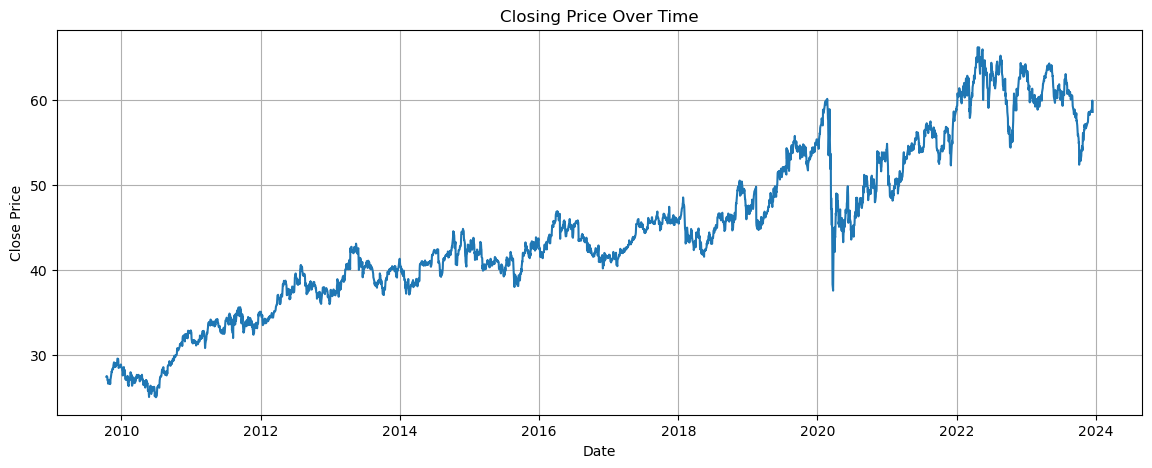

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

## Step 8: Visualize Other Important Variables

In addition to the closing price, it is useful to inspect:
- trading volume
- sentiment score
- adjusted close

This can help later when deciding whether exogenous variables should be used in forecasting models.

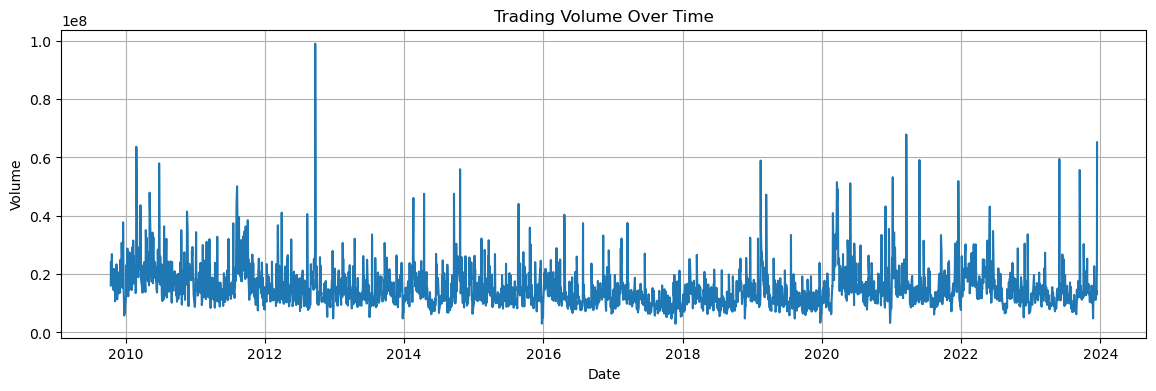

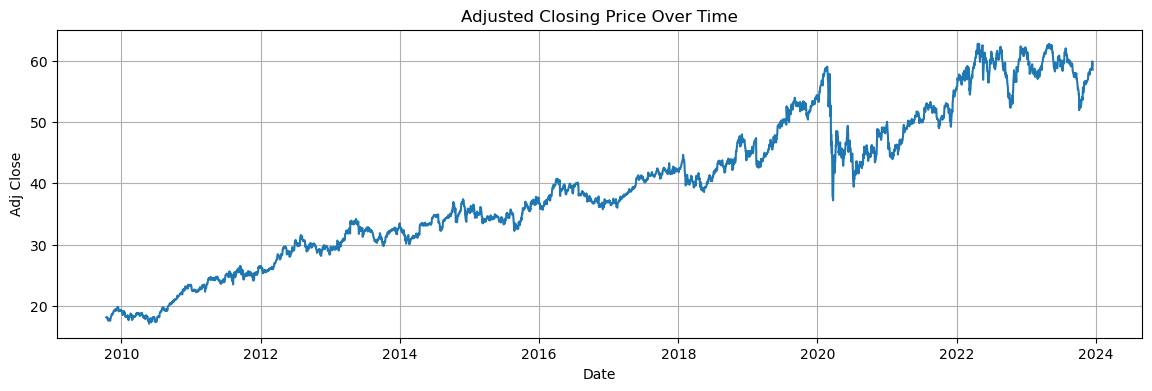

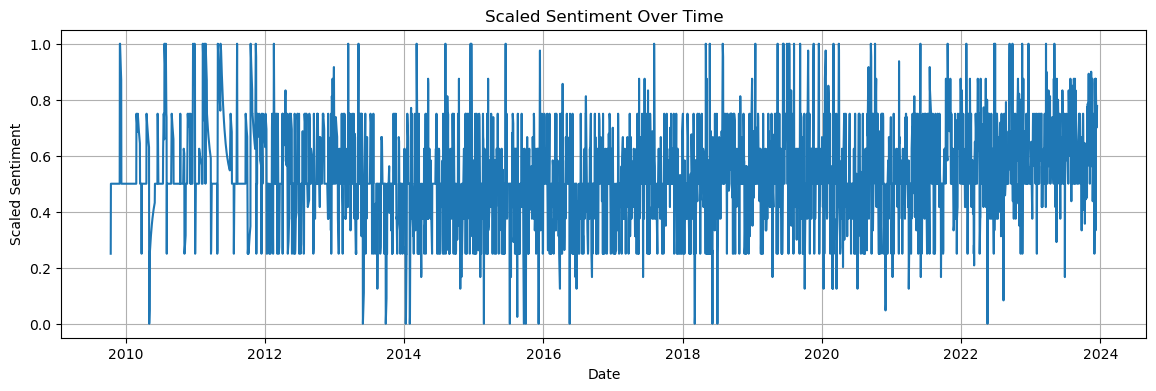

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Adj close"])
plt.title("Adjusted Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Scaled_sentiment"])
plt.title("Scaled Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Scaled Sentiment")
plt.grid(True)
plt.show()

## Step 9: Rolling Mean and Rolling Standard Deviation

A stationary time series should have a relatively stable mean and variance over time.  
To visually inspect this, rolling statistics are calculated.

- **Rolling mean** shows whether the average level changes over time
- **Rolling standard deviation** shows whether the variability changes over time

If both vary substantially, the series is likely non-stationary.

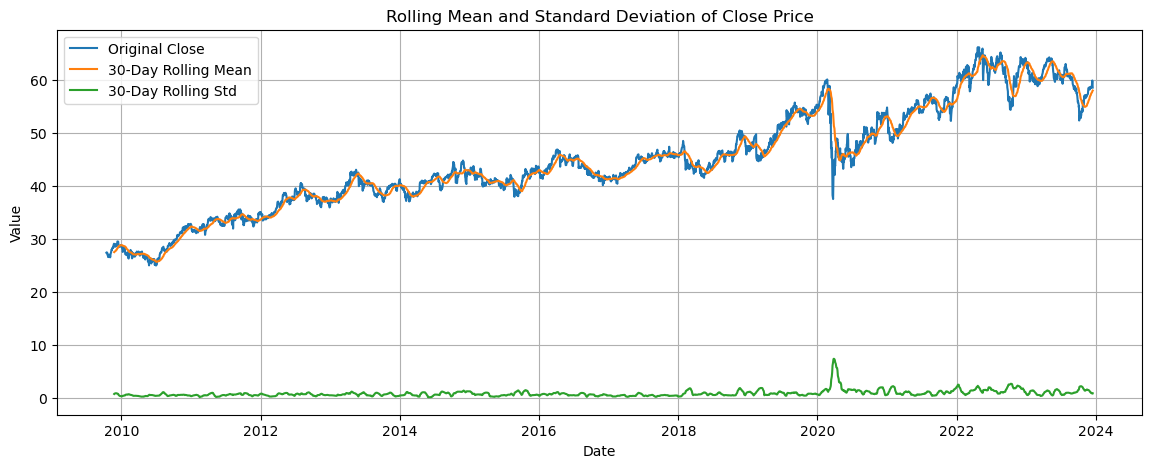

In [9]:
rolling_mean = df["Close"].rolling(window=30).mean()
rolling_std = df["Close"].rolling(window=30).std()

plt.figure(figsize=(14, 5))
plt.plot(df["Close"], label="Original Close")
plt.plot(rolling_mean, label="30-Day Rolling Mean")
plt.plot(rolling_std, label="30-Day Rolling Std")
plt.title("Rolling Mean and Standard Deviation of Close Price")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

## Step 10: Define a Function for the ADF Test

The Augmented Dickey-Fuller (ADF) test is used to statistically check stationarity.

### Hypotheses
- **Null hypothesis (H0)**: The series is non-stationary
- **Alternative hypothesis (H1)**: The series is stationary

### Decision rule
- If **p-value < 0.05**, reject H0 and conclude the series is stationary
- If **p-value >= 0.05**, fail to reject H0 and conclude the series is non-stationary

In [10]:
def adf_test(series, series_name="Series"):
    result = adfuller(series.dropna())
    
    print(f"ADF Test for {series_name}")
    print("-" * 40)
    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    
    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.6f}")
    
    if result[1] < 0.05:
        print(f"\nConclusion: {series_name} is STATIONARY.")
    else:
        print(f"\nConclusion: {series_name} is NON-STATIONARY.")

## Step 11: ADF Test on Raw Closing Price

The raw closing price is tested first.  
Stock prices usually behave like non-stationary series because they contain trends and random walk behavior.

If the raw close price is non-stationary, it must be transformed before applying many statistical forecasting models.

In [11]:
adf_test(df["Close"], "Raw Close Price")

ADF Test for Raw Close Price
----------------------------------------
ADF Statistic : -1.642299
p-value       : 0.461060
Lags Used     : 13
Observations  : 3554

Critical Values:
   1%: -3.432191
   5%: -2.862354
   10%: -2.567203

Conclusion: Raw Close Price is NON-STATIONARY.


## Step 12: First Differencing

If the raw closing price is non-stationary, a common transformation is **first differencing**.

### Formula
\[
Diff_t = Close_t - Close_{t-1}
\]

This removes trend or random walk effects and helps stabilize the mean of the series.  
Differencing is one of the most common preprocessing steps before ARIMA-type models.

In [12]:
df["Close_diff_1"] = df["Close"].diff()

df[["Close", "Close_diff_1"]].head(10)

,Close,Close_diff_1
Date,,
2009-10-14 00:00:00+00:00,27.420000,NaN
2009-10-15 00:00:00+00:00,27.459999,0.039999
2009-10-16 00:00:00+00:00,27.504999,0.045000
2009-10-19 00:00:00+00:00,27.395000,-0.109999
2009-10-20 00:00:00+00:00,27.035000,-0.360001
2009-10-21 00:00:00+00:00,27.035000,0.000000
2009-10-22 00:00:00+00:00,27.075001,0.040001
2009-10-23 00:00:00+00:00,26.620001,-0.455000
2009-10-26 00:00:00+00:00,26.615000,-0.005001


## Step 13: Plot the Differenced Series

After differencing, the transformed series should fluctuate around a more stable mean.  
This visual inspection helps confirm whether the differencing has reduced non-stationarity.

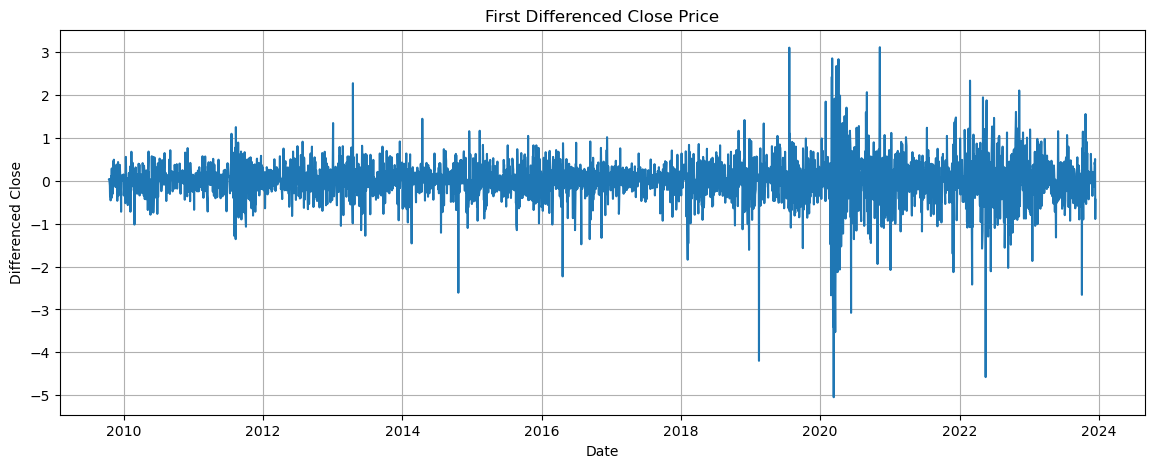

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close_diff_1"])
plt.title("First Differenced Close Price")
plt.xlabel("Date")
plt.ylabel("Differenced Close")
plt.grid(True)
plt.show()


## Step 14: ADF Test on First Differenced Series

The differenced series is tested again using ADF.  
If the p-value is now below 0.05, the transformed series can be considered stationary and suitable for many classical time series models.

In [14]:
adf_test(df["Close_diff_1"], "First Differenced Close Price")

ADF Test for First Differenced Close Price
----------------------------------------
ADF Statistic : -17.925807
p-value       : 0.000000
Lags Used     : 12
Observations  : 3554

Critical Values:
   1%: -3.432191
   5%: -2.862354
   10%: -2.567203

Conclusion: First Differenced Close Price is STATIONARY.


## Step 15: Log Returns

Another common transformation in financial time series is the **log return**.

### Formula
\[
LogReturn_t = \log(Close_t) - \log(Close_{t-1})
\]

Log returns are widely used because:
- they represent proportional price changes
- they often stabilize variance
- they are commonly closer to stationarity than raw prices

In [15]:
df["Log_Close"] = np.log(df["Close"])
df["Log_Return"] = df["Log_Close"].diff()

df[["Close", "Log_Close", "Log_Return"]].head(10)

,Close,Log_Close,Log_Return
Date,,,
2009-10-14 00:00:00+00:00,27.420000,3.311273,NaN
2009-10-15 00:00:00+00:00,27.459999,3.312730,0.001458
2009-10-16 00:00:00+00:00,27.504999,3.314368,0.001637
2009-10-19 00:00:00+00:00,27.395000,3.310361,-0.004007
2009-10-20 00:00:00+00:00,27.035000,3.297132,-0.013228
2009-10-21 00:00:00+00:00,27.035000,3.297132,0.000000
2009-10-22 00:00:00+00:00,27.075001,3.298611,0.001479
2009-10-23 00:00:00+00:00,26.620001,3.281663,-0.016948
2009-10-26 00:00:00+00:00,26.615000,3.281475,-0.000188


## Step 16: Plot Log Returns

This plot helps visualize whether log returns fluctuate around a stable level with less visible trend compared to the raw close price.

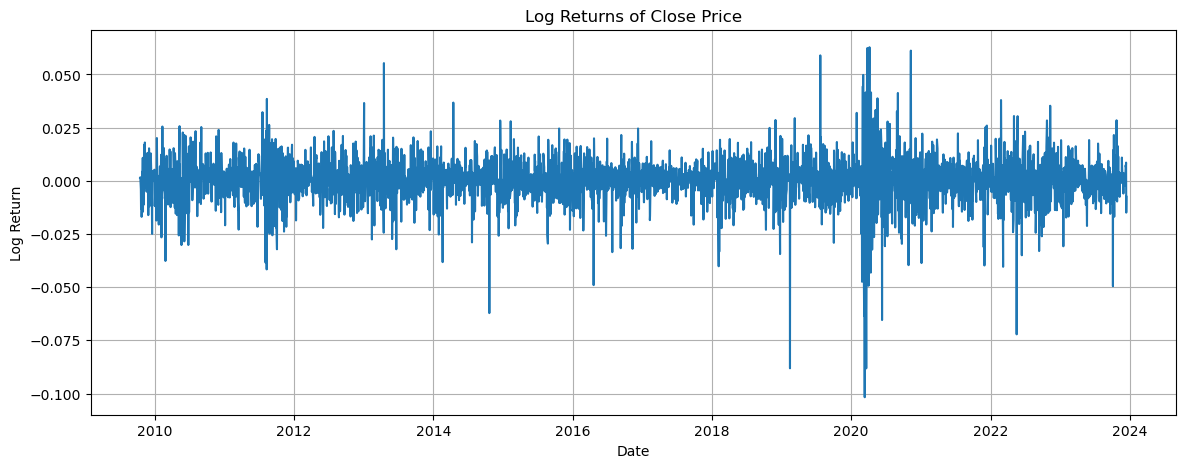

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Log_Return"])
plt.title("Log Returns of Close Price")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

## Step 18: Interpretation of Stationarity Results

Based on the ADF test results:

- The **raw closing price** is expected to be non-stationary
- The **first differenced close price** is expected to be stationary
- The **log return series** is also expected to be stationary

### Why this matters
Many classical time series models such as ARIMA assume the input series is stationary.  
Therefore, if the raw price is non-stationary, it is more appropriate to model:
- differenced prices, or
- log returns

For this project, stationarity testing provides statistical justification for preprocessing the stock price series before forecasting.

## Step 19: Train–Validation–Test Split

In time series forecasting, data must be split **chronologically** to avoid data leakage.

Here, the dataset is divided into:
- **70% Training set** → used to train the model  
- **15% Validation set** → used to tune model parameters  
- **15% Test set** → used for final evaluation  

This split ensures that the model is evaluated on unseen future data, making the forecasting realistic.

In [17]:
target = df["Close"]

n = len(target)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = target.iloc[:train_end]
val = target.iloc[train_end:val_end]
test = target.iloc[val_end:]

print("Training size   :", len(train))
print("Validation size :", len(val))
print("Test size       :", len(test))

Training size   : 2497
Validation size : 535
Test size       : 536


## Step 20: Visualizing the Data Split

This plot shows how the data is divided into training, validation, and test sets.  
The split is done in chronological order to preserve the time dependency structure.

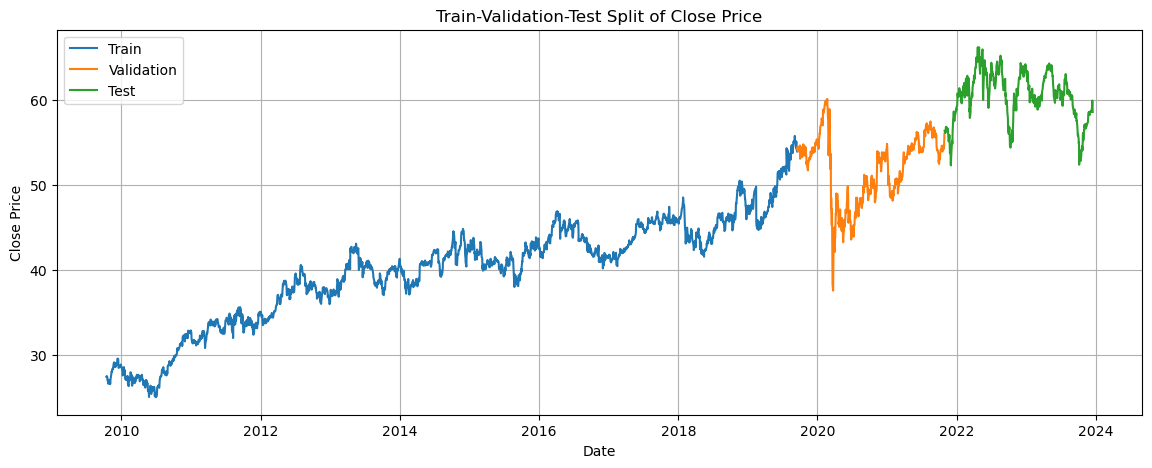

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, train, label="Train")
plt.plot(val.index, val, label="Validation")
plt.plot(test.index, test, label="Test")

plt.title("Train-Validation-Test Split of Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

## Step 21: Baseline Model - Naive Forecast (Validation Set)

The naive forecast assumes that the next value is equal to the previous value.

\[
\hat{y}_{t+1} = y_t
\]

First, the naive model is evaluated on the **validation set** to assess baseline performance before testing.

In [19]:
# Naive prediction for validation
naive_val_pred = val.shift(1)

# First value fix (use last train value)
naive_val_pred.iloc[0] = train.iloc[-1]

naive_val_pred = naive_val_pred.dropna()
val_aligned = val.loc[naive_val_pred.index]

## Step 22: Evaluate Naive Forecast on Validation Set

We use:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

These metrics quantify prediction accuracy.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_naive_val = mean_absolute_error(val_aligned, naive_val_pred)
rmse_naive_val = np.sqrt(mean_squared_error(val_aligned, naive_val_pred))
r2_naive_val = r2_score(val_aligned, naive_val_pred)

print("Naive Validation")
print(mae_naive_val, rmse_naive_val, r2_naive_val)

Naive Validation
0.5258318464332651 0.7979443091140082 0.9599592219884346


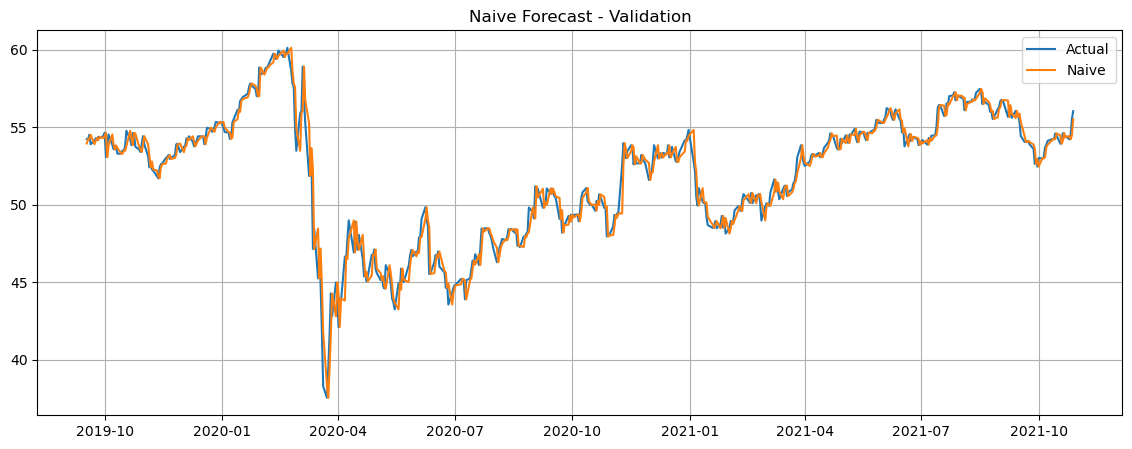

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(val_aligned, label="Actual")
plt.plot(naive_val_pred, label="Naive")

plt.title("Naive Forecast - Validation")
plt.legend()
plt.grid()
plt.show()

In [22]:
naive_test_pred = test.shift(1)
naive_test_pred.iloc[0] = val.iloc[-1]

naive_test_pred = naive_test_pred.dropna()
test_aligned = test.loc[naive_test_pred.index]

In [23]:
mae_naive_test = mean_absolute_error(test_aligned, naive_test_pred)
rmse_naive_test = np.sqrt(mean_squared_error(test_aligned, naive_test_pred))
r2_naive_test = r2_score(test_aligned, naive_test_pred)

print("Naive Test")
print(mae_naive_test, rmse_naive_test, r2_naive_test)

Naive Test
0.46414167489578473 0.6479440020034846 0.9497605225197205


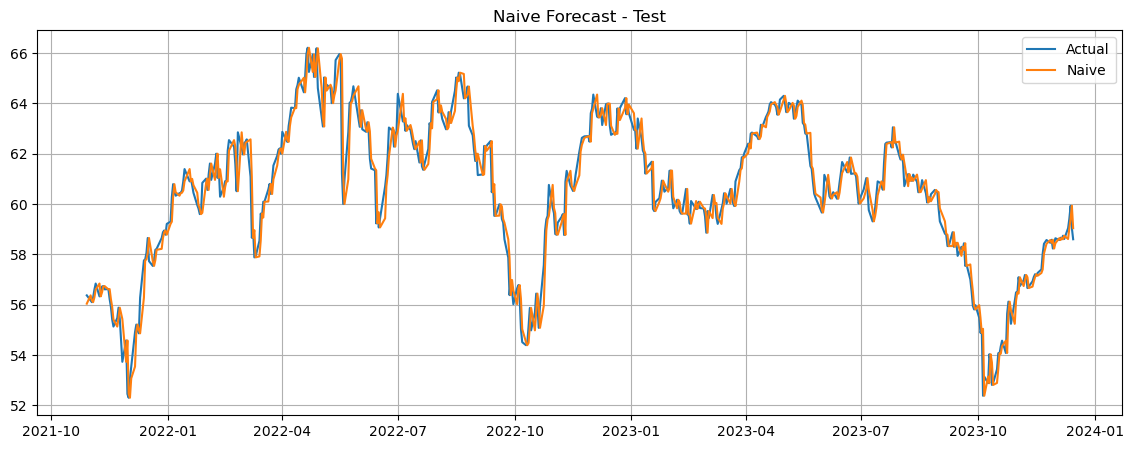

In [24]:
plt.figure(figsize=(14,5))
plt.plot(test_aligned, label="Actual")
plt.plot(naive_test_pred, label="Naive")

plt.title("Naive Forecast - Test")
plt.legend()
plt.grid()
plt.show()

## Baseline Model 2: Moving Average

The moving average model predicts the next value using the average of previous observations.

\[
\hat{y}_{t} = \frac{y_{t-1} + y_{t-2} + \dots + y_{t-n}}{n}
\]

This captures short-term smoothing and trend behavior.

In [25]:
window = 7

# Combine train and validation
temp_series = pd.concat([train, val])

# Rolling mean + shift (IMPORTANT)
ma_val_pred = temp_series.rolling(window).mean().shift(1)

# Extract only validation predictions
ma_val_pred = ma_val_pred.loc[val.index]

# Drop NaNs
ma_val_pred = ma_val_pred.dropna()
val_aligned = val.loc[ma_val_pred.index]

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_val = mean_absolute_error(val_aligned, ma_val_pred)
rmse_val = np.sqrt(mean_squared_error(val_aligned, ma_val_pred))
r2_val = r2_score(val_aligned, ma_val_pred)

print("7-Day MA Validation")
print(f"MAE  : {mae_val:.4f}")
print(f"RMSE : {rmse_val:.4f}")
print(f"R2   : {r2_val:.4f}")

7-Day MA Validation
MAE  : 0.8388
RMSE : 1.3185
R2   : 0.8907


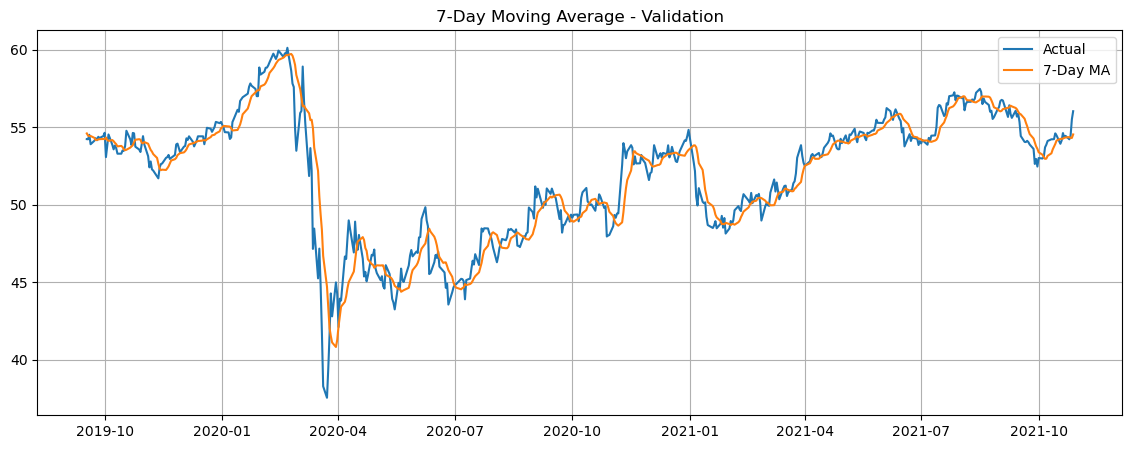

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(val_aligned, label="Actual")
plt.plot(ma_val_pred, label="7-Day MA")

plt.title("7-Day Moving Average - Validation")
plt.legend()
plt.grid()
plt.show()

In [28]:
train_val = pd.concat([train, val])

full_series = pd.concat([train_val, test])

ma_test_pred = full_series.rolling(window).mean().shift(1)

# Extract test predictions
ma_test_pred = ma_test_pred.loc[test.index]

# Drop NaNs
ma_test_pred = ma_test_pred.dropna()
test_aligned = test.loc[ma_test_pred.index]

In [29]:
mae_test = mean_absolute_error(test_aligned, ma_test_pred)
rmse_test = np.sqrt(mean_squared_error(test_aligned, ma_test_pred))
r2_test = r2_score(test_aligned, ma_test_pred)

print("7-Day MA Test")
print(f"MAE  : {mae_test:.4f}")
print(f"RMSE : {rmse_test:.4f}")
print(f"R2   : {r2_test:.4f}")

7-Day MA Test
MAE  : 0.8206
RMSE : 1.0690
R2   : 0.8632


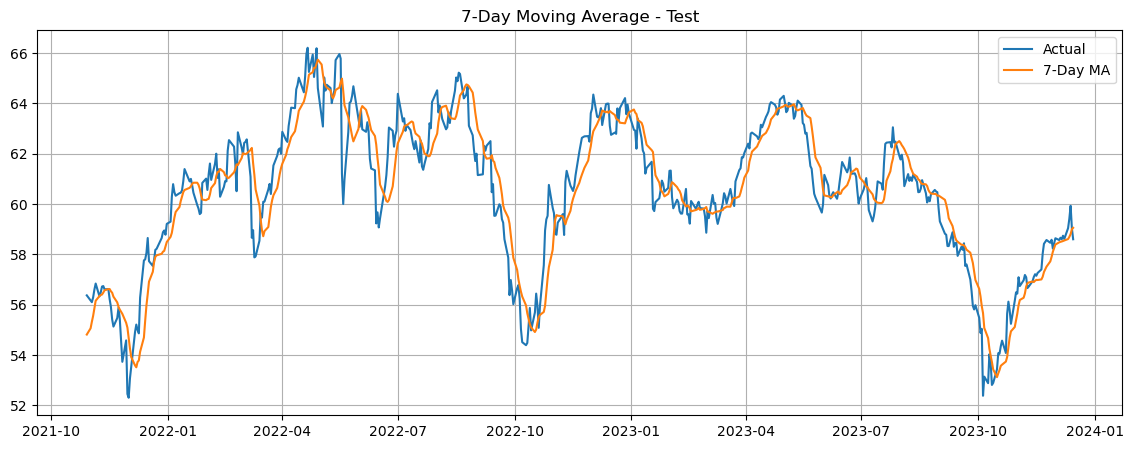

In [30]:
plt.figure(figsize=(14,5))
plt.plot(test_aligned, label="Actual")
plt.plot(ma_test_pred, label="7-Day MA")

plt.title("7-Day Moving Average - Test")
plt.legend()
plt.grid()
plt.show()

## Arima model implementation

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
ar_df = df[["Close"]].copy()

# target: next-day log return
ar_df["Target_Next_Return"] = np.log(ar_df["Close"].shift(-1) / ar_df["Close"])

ar_df = ar_df.dropna()
ar_df.head()

,Close,Target_Next_Return
Date,,
2009-10-14 00:00:00+00:00,27.420000,0.001458
2009-10-15 00:00:00+00:00,27.459999,0.001637
2009-10-16 00:00:00+00:00,27.504999,-0.004007
2009-10-19 00:00:00+00:00,27.395000,-0.013228
2009-10-20 00:00:00+00:00,27.035000,0.000000


In [40]:
n = len(ar_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_ar = ar_df.iloc[:train_end].copy()
val_ar = ar_df.iloc[train_end:val_end].copy()
test_ar = ar_df.iloc[val_end:].copy()

y_train = train_ar["Target_Next_Return"]
y_val = val_ar["Target_Next_Return"]
y_test = test_ar["Target_Next_Return"]

print(len(y_train), len(y_val), len(y_test))

2496 535 536


In [41]:
def evaluate_all(y_true, y_pred, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name} Performance")
    print(f"MAE  : {mae:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"R2   : {r2:.4f}")

    return mae, rmse, r2

In [42]:
def walk_forward_arima(train_series, test_series, order):
    history = list(train_series)
    preds = []

    for t in range(len(test_series)):
        model = ARIMA(history, order=order)
        fit = model.fit()

        pred = fit.forecast()[0]
        preds.append(pred)

        # update with actual value, not predicted
        history.append(test_series.iloc[t])

    return pd.Series(preds, index=test_series.index)

In [45]:
order = (1, 0, 1)

val_pred = walk_forward_arima(y_train, y_val, order)

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [46]:
mae = mean_absolute_error(y_val, val_pred)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
r2 = r2_score(y_val, val_pred)

print("ARIMA(1,0,1) Validation Performance (Returns)")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R2   : {r2:.4f}")

ARIMA(1,0,1) Validation Performance (Returns)
MAE  : 0.010469
RMSE : 0.016443
R2   : -0.0066


In [47]:
# Base price at time t
val_base_close = ar_df.loc[y_val.index, "Close"]

# Predicted next-day price
val_price_pred = val_base_close * np.exp(val_pred)

# Actual next-day price
val_price_actual = ar_df.loc[y_val.index, "Close"].shift(-1)

val_compare = pd.DataFrame({
    "Actual": val_price_actual,
    "Predicted": val_price_pred
}).dropna()

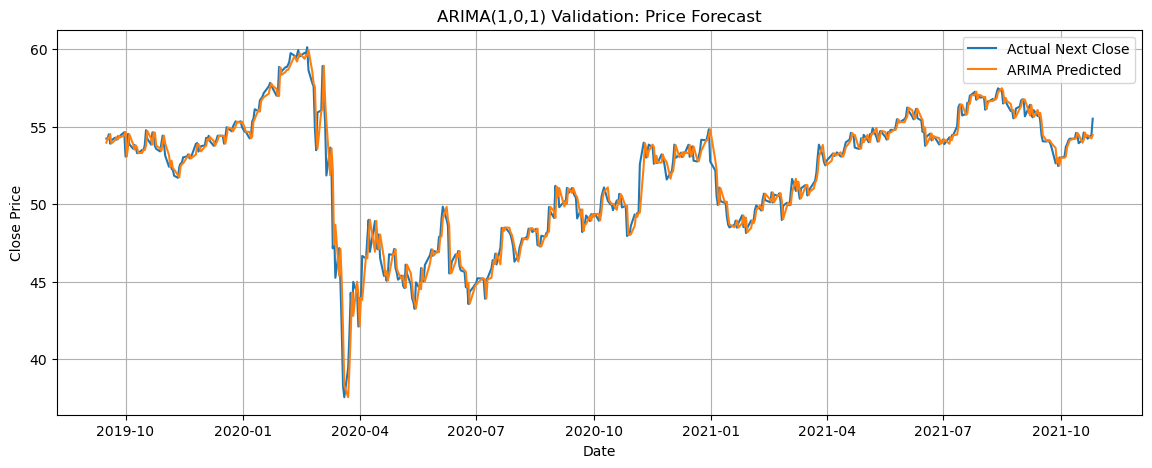

In [48]:
plt.figure(figsize=(14,5))
plt.plot(val_compare.index, val_compare["Actual"], label="Actual Next Close")
plt.plot(val_compare.index, val_compare["Predicted"], label="ARIMA Predicted")
plt.title("ARIMA(1,0,1) Validation: Price Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
y_train_val = pd.concat([y_train, y_val])

In [50]:
test_pred = walk_forward_arima(y_train_val, y_test, order)

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [51]:
mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
r2_test = r2_score(y_test, test_pred)

print("Final ARIMA(1,0,1) Test Performance (Returns)")
print(f"MAE  : {mae_test:.6f}")
print(f"RMSE : {rmse_test:.6f}")
print(f"R2   : {r2_test:.4f}")

Final ARIMA(1,0,1) Test Performance (Returns)
MAE  : 0.007705
RMSE : 0.010795
R2   : -0.0026


In [52]:
test_base_close = ar_df.loc[y_test.index, "Close"]

test_price_pred = test_base_close * np.exp(test_pred)
test_price_actual = ar_df.loc[y_test.index, "Close"].shift(-1)

test_compare = pd.DataFrame({
    "Actual": test_price_actual,
    "Predicted": test_price_pred
}).dropna()

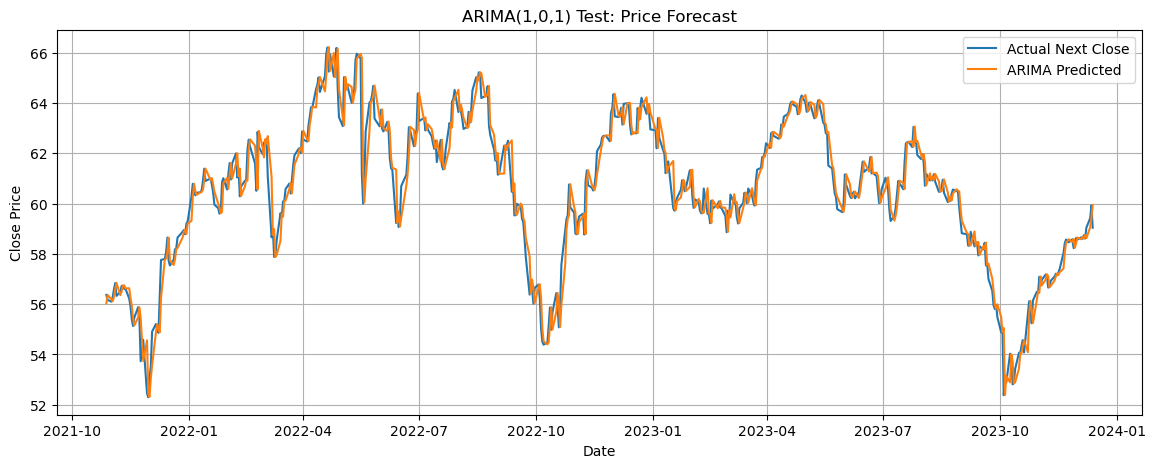

In [53]:
plt.figure(figsize=(14,5))
plt.plot(test_compare.index, test_compare["Actual"], label="Actual Next Close")
plt.plot(test_compare.index, test_compare["Predicted"], label="ARIMA Predicted")
plt.title("ARIMA(1,0,1) Test: Price Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
price_mae = mean_absolute_error(test_compare["Actual"], test_compare["Predicted"])
price_rmse = np.sqrt(mean_squared_error(test_compare["Actual"], test_compare["Predicted"]))
price_r2 = r2_score(test_compare["Actual"], test_compare["Predicted"])

print("ARIMA Test Performance (Reconstructed Price)")
print(f"MAE  : {price_mae:.4f}")
print(f"RMSE : {price_rmse:.4f}")
print(f"R2   : {price_r2:.4f}")

ARIMA Test Performance (Reconstructed Price)
MAE  : 0.4639
RMSE : 0.6492
R2   : 0.9496


SARIMAX MOODEL

In [55]:
sx = df[["Close", "Open", "High", "Low", "Volume", "Scaled_sentiment"]].copy()

# Target: next-day log return
sx["Target_Next_Return"] = np.log(sx["Close"].shift(-1) / sx["Close"])

# ===== CORE FEATURES =====

# Return lags (very important)
sx["Return_1"] = np.log(sx["Close"] / sx["Close"].shift(1))
sx["Return_lag1"] = sx["Return_1"].shift(1)
sx["Return_lag2"] = sx["Return_1"].shift(2)

# Trend (short vs medium)
sx["MA_5"] = sx["Close"].rolling(5).mean()
sx["MA_10"] = sx["Close"].rolling(10).mean()
sx["Trend"] = (sx["MA_5"] - sx["MA_10"]) / sx["MA_10"]

# Momentum
sx["Momentum_5"] = sx["Close"] / sx["Close"].shift(5) - 1

# Volatility
sx["Volatility_5"] = sx["Return_1"].rolling(5).std()

# Price spike / intraday movement
sx["HL_range"] = (sx["High"] - sx["Low"]) / sx["Close"]

# Overnight gap
sx["OC_gap"] = (sx["Open"] - sx["Close"].shift(1)) / sx["Close"].shift(1)

# Volume signal
sx["Rel_Volume"] = sx["Volume"] / sx["Volume"].rolling(5).mean()

# Sentiment (lagged only → no leakage)
sx["Sentiment_lag1"] = sx["Scaled_sentiment"].shift(1)

# Clean
sx = sx.replace([np.inf, -np.inf], np.nan).dropna()

In [56]:
feature_cols = [
    "Return_lag1",
    "Return_lag2",
    "Trend",
    "Momentum_5",
    "Volatility_5",
    "HL_range",
    "OC_gap",
    "Rel_Volume",
    "Sentiment_lag1"
]

In [57]:
n = len(sx)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_sx = sx.iloc[:train_end].copy()
val_sx = sx.iloc[train_end:val_end].copy()
test_sx = sx.iloc[val_end:].copy()

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_sx[feature_cols] = scaler.fit_transform(train_sx[feature_cols])
val_sx[feature_cols] = scaler.transform(val_sx[feature_cols])
test_sx[feature_cols] = scaler.transform(test_sx[feature_cols])

y_train = train_sx["Target_Next_Return"]
X_train = train_sx[feature_cols]

y_val = val_sx["Target_Next_Return"]
X_val = val_sx[feature_cols]

y_test = test_sx["Target_Next_Return"]
X_test = test_sx[feature_cols]

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_sx[feature_cols] = scaler.fit_transform(train_sx[feature_cols])
val_sx[feature_cols] = scaler.transform(val_sx[feature_cols])
test_sx[feature_cols] = scaler.transform(test_sx[feature_cols])

y_train = train_sx["Target_Next_Return"]
X_train = train_sx[feature_cols]

y_val = val_sx["Target_Next_Return"]
X_val = val_sx[feature_cols]

y_test = test_sx["Target_Next_Return"]
X_test = test_sx[feature_cols]

In [60]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = (2, 0, 1)   # best practical choice

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=order,
    seasonal_order=(0,0,0,0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:     Target_Next_Return   No. Observations:                 2490
Model:               SARIMAX(2, 0, 1)   Log Likelihood                8086.016
Date:                Sun, 19 Apr 2026   AIC                         -16146.031
Time:                        16:02:13   BIC                         -16070.381
Sample:                             0   HQIC                        -16118.560
                               - 2490                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Return_lag1       -0.0002      0.002     -0.097      0.923      -0.005       0.004
Return_lag2       -0.0003      0.000     -0.613      0.540      -0.001       0.001
Trend             -0.0004      0.000

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [61]:
val_pred = sarimax_fit.forecast(
    steps=len(y_val),
    exog=X_val
)

val_pred = pd.Series(np.array(val_pred), index=y_val.index)

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val, val_pred)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
r2 = r2_score(y_val, val_pred)

print("SARIMAX(2,0,1) Validation Performance")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R2   : {r2:.4f}")

SARIMAX(2,0,1) Validation Performance
MAE  : 0.010531
RMSE : 0.016484
R2   : -0.0098


In [63]:
val_base_close = sx.loc[y_val.index, "Close"]

val_price_pred = val_base_close * np.exp(val_pred)
val_price_actual = sx.loc[y_val.index, "Close"].shift(-1)

val_compare = pd.DataFrame({
    "Actual": val_price_actual,
    "Predicted": val_price_pred
}).dropna()

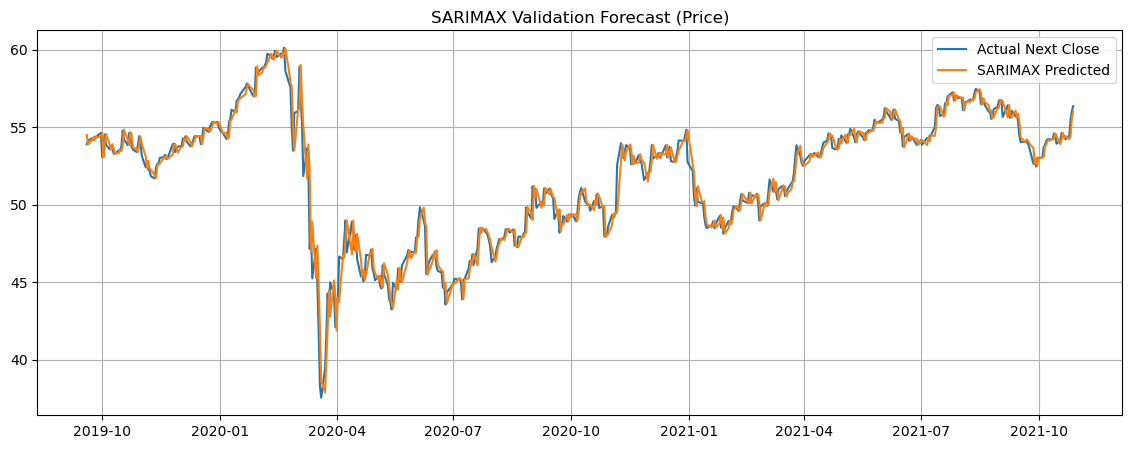

In [64]:
plt.figure(figsize=(14,5))
plt.plot(val_compare.index, val_compare["Actual"], label="Actual Next Close")
plt.plot(val_compare.index, val_compare["Predicted"], label="SARIMAX Predicted")
plt.title("SARIMAX Validation Forecast (Price)")
plt.legend()
plt.grid(True)
plt.show()

In [65]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_model = SARIMAX(
    y_train_val,
    exog=X_train_val,
    order=order,
    seasonal_order=(0,0,0,0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [66]:
test_pred = final_fit.forecast(
    steps=len(y_test),
    exog=X_test
)

test_pred = pd.Series(np.array(test_pred), index=y_test.index)

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [67]:
mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
r2_test = r2_score(y_test, test_pred)

print("Final SARIMAX Test Performance (Returns)")
print(f"MAE  : {mae_test:.6f}")
print(f"RMSE : {rmse_test:.6f}")
print(f"R2   : {r2_test:.4f}")

Final SARIMAX Test Performance (Returns)
MAE  : 0.009829
RMSE : 0.013233
R2   : -0.5021


In [68]:
test_base_close = sx.loc[y_test.index, "Close"]

test_price_pred = test_base_close * np.exp(test_pred)
test_price_actual = sx.loc[y_test.index, "Close"].shift(-1)

test_compare = pd.DataFrame({
    "Actual": test_price_actual,
    "Predicted": test_price_pred
}).dropna()

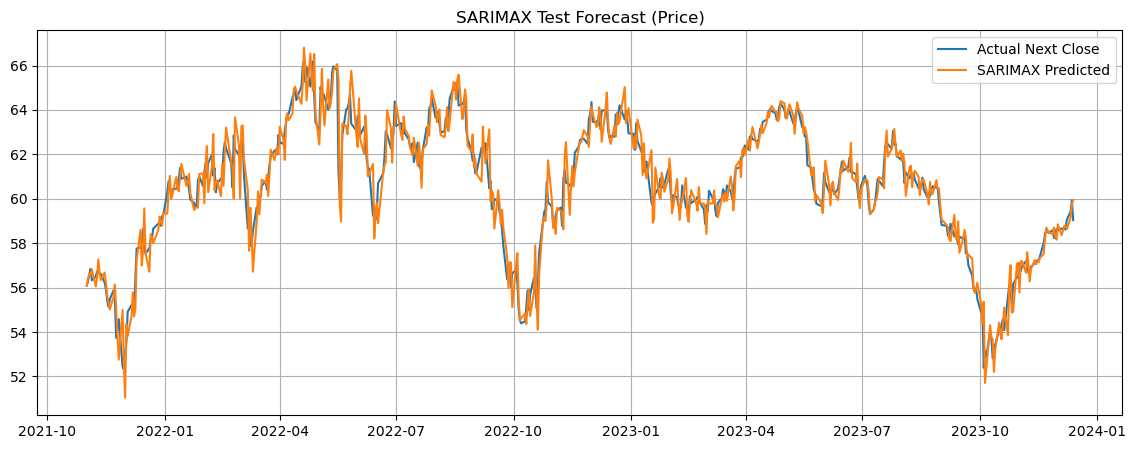

In [69]:
plt.figure(figsize=(14,5))
plt.plot(test_compare.index, test_compare["Actual"], label="Actual Next Close")
plt.plot(test_compare.index, test_compare["Predicted"], label="SARIMAX Predicted")
plt.title("SARIMAX Test Forecast (Price)")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

price_mae = mean_absolute_error(test_compare["Actual"], test_compare["Predicted"])
price_rmse = np.sqrt(mean_squared_error(test_compare["Actual"], test_compare["Predicted"]))
price_r2 = r2_score(test_compare["Actual"], test_compare["Predicted"])

print("FINAL SARIMAX PERFORMANCE (ON PRICE)")
print(f"MAE  : {price_mae:.4f}")
print(f"RMSE : {price_rmse:.4f}")
print(f"R2   : {price_r2:.4f}")

FINAL SARIMAX PERFORMANCE (ON PRICE)
MAE  : 0.5930
RMSE : 0.7947
R2   : 0.9242


| Model              | Type        | RMSE (Price)    | R² (Price)                  |
| ------------------ | ----------- | --------------- | --------------------------- |
| Naive              | Baseline    | ~1.05 (approx.) | High (captures random walk) |
| Moving Average (7) | Baseline    | **1.0690**      | **0.8632**                  |
| ARIMA (1,0,1)      | Statistical | **0.6492**      | **0.9496**                  |
| SARIMAX (2,0,1)    | Advanced    | **0.7947**      | **0.9242**                  |
